In [35]:
import os, re, random, json
from typing import List, Tuple, Dict, Optional

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import joblib

import matplotlib.pyplot as plt

# ==============================
# paths
# ==============================
OPERATING_XLSX   = "./output/Decision_variablesRU.xlsx"  # targets p-MM-YYYY
ELEC_LOAD_XLSX   = "./input/Elec Load Data.xlsx"         # inputs elec
GAS_NETWORK_XLSX = "./Gas Network Data.xlsx"       # optional static

# ==============================
# day-ahead setup
# ==============================
HIST_HOURS = 72
HORIZON_HOURS = 24
STRIDE = 24              # stride=1 for training windows, stride=24 for operational style evaluation
USE_STATIC = False      # set True if you want to add static_vec to every x

# ==============================
# train setup (editable)
# ==============================
SEED = 42
BATCH_SIZE = 64
EPOCHS = 500
LR = 5e-4 
DROPOUT = 0.15
HIDDEN_SIZES = [1024, 1024, 512]
PATIENCE = 25

# ==============================
# train setup (editable)
# ==============================
SEED = 42
BATCH_SIZE = 24   #50
EPOCHS = 800
LR = 7e-4  #1e-4
DROPOUT = 0.4  #0.01
HIDDEN_SIZES = [512, 512, 256]
PATIENCE = 30  #10

# scheduler (editable)
USE_SCHEDULER = True
SCHED_FACTOR = 0.7  #0.5
SCHED_PATIENCE = 7   #5
MIN_LR = 1e-6  #1e-7

# split time (editable)
SPLIT_TS = "2024-11-01 00:00:00"

# output dir
OUT_DIR = "./runs_mlp_elec_only"
os.makedirs(OUT_DIR, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEVICE)

device: cuda


In [36]:
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)
print("seed set to", SEED)

# keep only numerical values (float/int)
def clean_numeric_df(df: pd.DataFrame) -> pd.DataFrame:
    drop_cols = [c for c in df.columns if str(c).startswith("Unnamed")]
    df = df.drop(columns=drop_cols, errors="ignore")
    df = df.select_dtypes(include=[np.number])
    return df

def has_nan(arr: np.ndarray) -> bool:
    return np.isnan(arr).any()

def has_inf(arr: np.ndarray) -> bool:
    return np.isinf(arr).any()

def rmse_flat(y_true_flat, y_pred_flat) -> float:
    return float(np.sqrt(mean_squared_error(y_true_flat, y_pred_flat)))

TIME_CANDIDATES = ["Date Time", "Datetime", "date time", "datetime", "DateTime", "DATE TIME", "DATETIME", "timestamp", "Timestamp", "TIME", "Time"]

def extract_datetime_and_numeric(df: pd.DataFrame):
    time_col = None
    for c in df.columns:
        if str(c) in TIME_CANDIDATES:
            time_col = c
            break
    if time_col is None:
        num = df.select_dtypes(include=[np.number]).copy()
        return None, num
    dt = pd.to_datetime(df[time_col], errors="coerce")
    num = df.drop(columns=[time_col], errors="ignore").select_dtypes(include=[np.number]).copy()
    return dt, num

seed set to 42


In [37]:
def list_months_in_operating_excel_p(xlsx_path: str) -> List[Tuple[str, str]]:
    xls = pd.ExcelFile(xlsx_path)
    sheets = [s.strip() for s in xls.sheet_names]
    pattern = re.compile(r"^p-(\d{2})-(\d{4})$")  # only p-MM-YYYY
    months_ok = []
    for s in sheets:
        m = pattern.match(s)
        if m:
            mo, yr = m.group(1), m.group(2)
            months_ok.append((mo, yr))
    months_ok = sorted(months_ok, key=lambda x: (x[1], x[0]))
    return months_ok

def inspect_operating_p(xlsx_path: str, n_preview: int = 2):
    xls = pd.ExcelFile(xlsx_path)
    months_ok = list_months_in_operating_excel_p(xlsx_path)
    print("nb sheets:", len(xls.sheet_names))
    print("p months:", months_ok)

    if len(months_ok) == 0:
        raise ValueError("no p-MM-YYYY sheets found")

    # preview first month
    mo, yr = months_ok[0]
    sh = f"p-{mo}-{yr}"
    raw = pd.read_excel(xlsx_path, sheet_name=sh)
    print("sample sheet:", sh, "| raw shape:", raw.shape)
    print("raw columns:", raw.columns.tolist())
    print("raw dtypes head:\n", raw.dtypes.head(10))
    print(raw.head(n_preview))
    return months_ok

months_available = inspect_operating_p(OPERATING_XLSX)

nb sheets: 72
p months: [('01', '2024'), ('02', '2024'), ('03', '2024'), ('04', '2024'), ('05', '2024'), ('06', '2024'), ('07', '2024'), ('08', '2024'), ('09', '2024'), ('10', '2024'), ('11', '2024'), ('12', '2024')]
sample sheet: p-01-2024 | raw shape: (744, 25)
raw columns: ['Unnamed: 0', 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
raw dtypes head:
 Unnamed: 0      int64
0             float64
1             float64
2             float64
3             float64
4             float64
5             float64
6             float64
7             float64
8             float64
dtype: object
   Unnamed: 0    0    1      2    3    4    5    6         7    8  ...   14  \
0           0  0.0  0.0  10.26  0.0  0.0  0.0  0.0  3.655508  0.0  ...  0.0   
1           1  0.0  0.0  10.26  0.0  0.0  0.0  0.0  2.260725  0.0  ...  0.0   

    15   16   17   18   19   20    21   22   23  
0  0.0  0.0  0.0  0.0  0.0  0.0  10.3  0.0  0.0  
1  0.0  0.0  0.0  0.0  0.0  0.0 

In [38]:
def read_month_sheet_p(xls: pd.ExcelFile, sheet: str) -> pd.DataFrame:
    df = pd.read_excel(xls, sheet_name=sheet)
    df = clean_numeric_df(df)
    return df

def load_targets_p_long(operating_xlsx_path: str,
                        months_to_load: List[Tuple[str,str]]) -> pd.DataFrame:
    """
    df_long contains:
    - p_* columns (P gfpp)
    - year, month, t (hour in the month: 0..n-1)
    """
    xls = pd.ExcelFile(operating_xlsx_path)
    all_rows = []

    for (mo, yr) in months_to_load:
        sh_p = f"p-{mo}-{yr}"
        p = read_month_sheet_p(xls, sh_p)

        # keep only numeric cols, no invention
        p = p.select_dtypes(include=[np.number])
        n = len(p)

        df = p.add_prefix("p_").copy()
        df["month"] = mo
        df["year"]  = yr
        df["t"]     = np.arange(n)
        all_rows.append(df)

    df_long = pd.concat(all_rows, ignore_index=True)
    return df_long

def make_continuous_ts_from_year_month_t(df: pd.DataFrame) -> pd.DataFrame:
    df2 = df.copy()
    df2["year_i"] = df2["year"].astype(int)
    df2["month_i"] = df2["month"].astype(int)
    start = pd.to_datetime(df2["year_i"].astype(str) + "-" + df2["month_i"].astype(str).str.zfill(2) + "-01 00:00:00")
    df2["ts"] = start + pd.to_timedelta(df2["t"].astype(int), unit="h")
    df2 = df2.sort_values("ts").reset_index(drop=True)
    return df2

df_p_long = load_targets_p_long(OPERATING_XLSX, months_available)
df_p_all = make_continuous_ts_from_year_month_t(df_p_long)

P = sum(str(c).startswith("p_") for c in df_p_all.columns)
print("df_p_all shape:", df_p_all.shape)
print("nb p columns (P):", P)
print("ts monotonic:", df_p_all["ts"].is_monotonic_increasing)
print(df_p_all[["ts","year","month","t"]].head(3))
print(df_p_all.filter(regex=r"^p_").head(2))

df_p_all shape: (8784, 30)
nb p columns (P): 24
ts monotonic: True
                   ts  year month  t
0 2024-01-01 00:00:00  2024    01  0
1 2024-01-01 01:00:00  2024    01  1
2 2024-01-01 02:00:00  2024    01  2
   p_0  p_1    p_2  p_3  p_4  p_5  p_6       p_7  p_8  p_9  ...  p_14  p_15  \
0  0.0  0.0  10.26  0.0  0.0  0.0  0.0  3.655508  0.0  0.0  ...   0.0   0.0   
1  0.0  0.0  10.26  0.0  0.0  0.0  0.0  2.260725  0.0  0.0  ...   0.0   0.0   

   p_16  p_17  p_18  p_19  p_20  p_21  p_22  p_23  
0   0.0   0.0   0.0   0.0   0.0  10.3   0.0   0.0  
1   0.0   0.0   0.0   0.0   0.0  10.3   0.0   0.0  

[2 rows x 24 columns]


In [39]:
def inspect_excel_quick(path: str, max_sheets: int = 30):
    print(f"\n=== inspect: {path} ===")
    if not os.path.exists(path):
        print("[warn] file not found")
        return
    xls = pd.ExcelFile(path)
    print("nb sheets:", len(xls.sheet_names))
    print("sheets:", xls.sheet_names[:max_sheets], "..." if len(xls.sheet_names) > max_sheets else "")

    sh = xls.sheet_names[0]
    df = pd.read_excel(path, sheet_name=sh)
    print(f"sample sheet '{sh}' shape:", df.shape)
    print("columns:", df.columns.tolist())
    print("dtypes head:\n", df.dtypes.head(10))
    print(df.head(2))

inspect_excel_quick(ELEC_LOAD_XLSX)

def load_monthly_consumption_elec(path: str, sheet: str, prefix: str):
    df = pd.read_excel(path, sheet_name=sheet)
    dt, num = extract_datetime_and_numeric(df)
    num = num.add_prefix(prefix)
    return dt, num

def build_consumption_e_all(df_p_all: pd.DataFrame,
                            months: List[Tuple[str,str]],
                            elec_path: str) -> pd.DataFrame:
    """
    build elec consumption yearly df aligned with df_p_all['ts'] (left merge on ts).
    - if datetime exists: build ts from it
    - else: fallback to "month start + t hours"
    """
    cons_blocks = []

    for (mo, yr) in months:
        sheet = f"{mo}-{yr}"  # expected monthly sheets

        dt_el, elec_num = load_monthly_consumption_elec(elec_path, sheet, prefix="elec__")

        elec_num = elec_num.select_dtypes(include=[np.number])
        n = len(elec_num)
        if dt_el is not None:
            dt_el = dt_el.iloc[:n]

        cons_m = elec_num.reset_index(drop=True).copy()

        # build ts
        if dt_el is not None and dt_el.notna().any():
            cons_m["ts"] = pd.to_datetime(dt_el, errors="coerce")
        else:
            # fallback: month start + t hours
            start = pd.Timestamp(f"{int(yr)}-{mo}-01 00:00:00")
            cons_m["ts"] = start + pd.to_timedelta(np.arange(n), unit="h")

        # clean numeric
        cons_m = cons_m.replace([np.inf, -np.inf], np.nan)
        cons_m = cons_m.apply(pd.to_numeric, errors="coerce")
        cons_m = cons_m.interpolate(limit_direction="both").fillna(0.0)

        cons_blocks.append(cons_m)

    cons_raw = pd.concat(cons_blocks, ignore_index=True)
    cons_raw = cons_raw.sort_values("ts").reset_index(drop=True)

    # force ts to datetime on both sides (avoid merge dtype mismatch)
    df_p_all["ts"] = pd.to_datetime(df_p_all["ts"], errors="coerce")
    cons_raw["ts"] = pd.to_datetime(cons_raw["ts"], errors="coerce")
    cons_raw = cons_raw.dropna(subset=["ts"]).copy()

    # left merge on ts to match df_p_all exactly
    cons_e_all = df_p_all[["ts"]].merge(cons_raw, on="ts", how="left", validate="1:1")

    # drop ts for features array later (we keep ts separately)
    cons_feat = cons_e_all.drop(columns=["ts"])
    cons_feat = cons_feat.replace([np.inf, -np.inf], np.nan)
    cons_feat = cons_feat.apply(pd.to_numeric, errors="coerce")
    cons_feat = cons_feat.interpolate(limit_direction="both").fillna(0.0)

    cons_e_all = pd.concat([df_p_all[["ts"]], cons_feat], axis=1)

    print("cons_e_all shape:", cons_e_all.shape)
    print("any nan in cons feats?", cons_e_all.drop(columns=["ts"]).isna().any().any())
    return cons_e_all

cons_e_all = build_consumption_e_all(
    df_p_all=df_p_all,
    months=months_available,
    elec_path=ELEC_LOAD_XLSX
)

print("dyn_per_hour (elec features):", cons_e_all.drop(columns=["ts"]).shape[1])
print(cons_e_all.head(2))


=== inspect: ./input/Elec Load Data.xlsx ===
nb sheets: 13
sheets: ['Year 2024', '01-2024', '02-2024', '03-2024', '04-2024', '05-2024', '06-2024', '07-2024', '08-2024', '09-2024', '10-2024', '11-2024', '12-2024'] 
sample sheet 'Year 2024' shape: (8784, 2)
columns: ['Datetime', 'Measured & Upscaled [MW]']
dtypes head:
 Datetime                     object
Measured & Upscaled [MW]    float64
dtype: object
                    Datetime  Measured & Upscaled [MW]
0  2024-01-01T00:00:00+01:00                4676.49425
1  2024-01-01T01:00:00+01:00                4537.01600
cons_e_all shape: (8784, 3)
any nan in cons feats? False
dyn_per_hour (elec features): 2
                   ts  elec__Measured & Upscaled [MW]  elec__Max Load [MW]
0 2024-01-01 00:00:00                      4676.49425           11647.6065
1 2024-01-01 01:00:00                      4537.01600           11647.6065


In [40]:
def load_static_network_vector(gas_network_xlsx: str) -> Dict:
    xls = pd.ExcelFile(gas_network_xlsx)

    # helpers
    def drop_unnamed(df: pd.DataFrame) -> pd.DataFrame:
        return df.drop(columns=[c for c in df.columns if str(c).startswith("Unnamed")], errors="ignore")

    def to_flat_numeric(df: pd.DataFrame, cols: Optional[List[str]] = None) -> np.ndarray:
        if cols is not None:
            cols = [c for c in cols if c in df.columns]
            df = df[cols]
        df = df.select_dtypes(include=[np.number])
        arr = df.to_numpy().reshape(-1)
        arr = np.nan_to_num(arr, nan=0.0, posinf=0.0, neginf=0.0)
        return arr.astype(np.float32)

    # minimal static (not perfect for elec, but optional baseline)
    nodes = drop_unnamed(pd.read_excel(xls, "Nodes"))
    node_cols_wanted = ["Res_Load_share_%", "Ind_Load_share_%", "Exp_Load_share_%", "Pr_min [bar]", "Pr_max [bar]"]
    node_static = to_flat_numeric(nodes, cols=node_cols_wanted)

    gfppmap = drop_unnamed(pd.read_excel(xls, "GFPPMap"))
    gfppmap = to_flat_numeric(gfppmap, cols=None)

    static_vec = np.concatenate([node_static, gfppmap]).astype(np.float32)
    static_vec = np.nan_to_num(static_vec, nan=0.0, posinf=0.0, neginf=0.0)

    info = {"static_vec": static_vec, "static_dim": int(static_vec.size)}
    print("static_dim:", info["static_dim"], "| nan:", np.isnan(static_vec).any())
    return info

static = None
if USE_STATIC:
    static = load_static_network_vector(GAS_NETWORK_XLSX)
else:
    static = {"static_vec": np.zeros(0, dtype=np.float32), "static_dim": 0}
print("use_static:", USE_STATIC, "| static_dim:", static["static_dim"])

use_static: False | static_dim: 0


In [41]:
def build_day_ahead_windows_elec(df_p_all: pd.DataFrame,
                                cons_e_all: pd.DataFrame,
                                static_vec: np.ndarray,
                                hist_hours: int = 72,
                                horizon_hours: int = 24,
                                stride: int = 1,
                                use_static: bool = False):
    """
    input  = hist_hours past elec consumption
    output = horizon_hours future p only
    """
    # target p (find p_ in the file)
    Y_p_cols = [c for c in df_p_all.columns if str(c).startswith("p_")]
    P = len(Y_p_cols)
    if P == 0:
        raise ValueError("no p_ columns found in df_p_all")

    # every columns as features (elec only)
    X_dyn_cols = [c for c in cons_e_all.columns if c != "ts"]
    dyn_per_hour = len(X_dyn_cols)
    if dyn_per_hour == 0:
        raise ValueError("no elec consumption columns found")

    # transformation into arrays
    X_dyn = cons_e_all[X_dyn_cols].to_numpy(dtype=np.float32)
    X_dyn = np.nan_to_num(X_dyn, nan=0.0, posinf=0.0, neginf=0.0)

    Y_p = df_p_all[Y_p_cols].to_numpy(dtype=np.float32)
    Y_p = np.nan_to_num(Y_p, nan=0.0, posinf=0.0, neginf=0.0)

    # cleaning static vec
    static_vec = np.asarray(static_vec, dtype=np.float32)
    static_vec = np.nan_to_num(static_vec, nan=0.0, posinf=0.0, neginf=0.0)

    ts = df_p_all["ts"].to_numpy()

    # gap detection (if a gap exists, we skip windows crossing the gap)
    dt = np.diff(ts).astype("timedelta64[h]").astype(int)
    gap_positions = np.where(dt != 1)[0]
    has_gaps = len(gap_positions) > 0
    if has_gaps:
        print(f"[warn] found {len(gap_positions)} gaps where ts step != 1 hour, skipping crossing windows")

    X_list, y_list, win_ts = [], [], []
    N = len(df_p_all)

    for t0 in range(hist_hours, N - horizon_hours + 1, stride):
        if has_gaps:
            start = t0 - hist_hours
            end = t0 + horizon_hours - 1
            if np.any(dt[start:end] != 1):
                continue

        # x history
        x_hist = X_dyn[t0 - hist_hours:t0, :]  # (72, dyn_per_hour)
        x_flat = x_hist.reshape(-1)

        if use_static and static_vec.size > 0:
            x_flat = np.concatenate([x_flat, static_vec], axis=0)

        # y future p only
        y_p_24 = Y_p[t0:t0 + horizon_hours, :].reshape(-1)  # (24*P,)
        X_list.append(x_flat)
        y_list.append(y_p_24)
        win_ts.append(ts[t0])

    X = np.stack(X_list).astype(np.float32)
    y = np.stack(y_list).astype(np.float32)
    win_ts = np.array(win_ts)

    meta = {
        "hist_hours": int(hist_hours),
        "horizon_hours": int(horizon_hours),
        "stride": int(stride),
        "dyn_per_hour": int(dyn_per_hour),
        "static_dim": int(static_vec.size),
        "X_dim": int(X.shape[1]),
        "y_dim": int(y.shape[1]),
        "P": int(P),
        "X_dyn_cols": X_dyn_cols,
        "Y_p_cols": Y_p_cols,
        "n_windows": int(X.shape[0]),
    }
    return X, y, win_ts, meta

X_e, y_p, win_ts, meta = build_day_ahead_windows_elec(
    df_p_all=df_p_all,
    cons_e_all=cons_e_all,
    static_vec=static["static_vec"],
    hist_hours=HIST_HOURS,
    horizon_hours=HORIZON_HOURS,
    stride=STRIDE,
    use_static=USE_STATIC
)

print("X_e shape:", X_e.shape, "(n_windows, X_dim)")
print("y_p shape:", y_p.shape, "(n_windows, 24*P attendu)")
print("meta:", {k: meta[k] for k in ["hist_hours","horizon_hours","stride","dyn_per_hour","static_dim","X_dim","y_dim","P","n_windows"]})
print("nan in X?", has_nan(X_e), "| inf in X?", has_inf(X_e))
print("nan in y?", has_nan(y_p), "| inf in y?", has_inf(y_p))

X_e shape: (363, 144) (n_windows, X_dim)
y_p shape: (363, 576) (n_windows, 24*P attendu)
meta: {'hist_hours': 72, 'horizon_hours': 24, 'stride': 24, 'dyn_per_hour': 2, 'static_dim': 0, 'X_dim': 144, 'y_dim': 576, 'P': 24, 'n_windows': 363}
nan in X? False | inf in X? False
nan in y? False | inf in y? False


In [42]:
months = pd.to_datetime(win_ts).month

# Train = décembre + janvier à août
train_mask = pd.Series(months).isin([12, 1, 2, 3, 4, 5, 6, 7, 8]).to_numpy()

# Validation = septembre
val_mask = (months == 9)

# Test = octobre
test_mask = (months == 10)

# Novembre ignoré
used_mask = train_mask | val_mask | test_mask

X_used  = X_e[used_mask]
y_used  = y_p[used_mask]
ts_used = win_ts[used_mask]

train_mask = train_mask[used_mask]
val_mask   = val_mask[used_mask]
test_mask  = test_mask[used_mask]

X_train, y_train = X_used[train_mask], y_used[train_mask]
X_val,   y_val   = X_used[val_mask],   y_used[val_mask]
X_test,  y_test  = X_used[test_mask],  y_used[test_mask]

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val  :", X_val.shape,   "y_val  :", y_val.shape)
print("X_test :", X_test.shape,  "y_test :", y_test.shape)

X_train: (272, 144) y_train: (272, 576)
X_val  : (30, 144) y_val  : (30, 576)
X_test : (31, 144) y_test : (31, 576)


In [43]:
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_s = scaler_X.fit_transform(X_train)
X_val_s   = scaler_X.transform(X_val)

y_train_s = scaler_y.fit_transform(y_train)
y_val_s   = scaler_y.transform(y_val)

joblib.dump(scaler_X, os.path.join(OUT_DIR, "scaler_X.pkl"))
joblib.dump(scaler_y, os.path.join(OUT_DIR, "scaler_y.pkl"))

print("scaled shapes:", X_train_s.shape, y_train_s.shape)
print("any nan scaled X?", np.isnan(X_train_s).any(), np.isnan(X_val_s).any())
print("any nan scaled y?", np.isnan(y_train_s).any(), np.isnan(y_val_s).any())

scaled shapes: (272, 144) (272, 576)
any nan scaled X? False False
any nan scaled y? False False


In [44]:
class NumpyDataset(Dataset):
    def __init__(self, X_np: np.ndarray, y_np: np.ndarray):
        self.X = torch.from_numpy(X_np).float()
        self.y = torch.from_numpy(y_np).float()

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_ds = NumpyDataset(X_train_s.astype(np.float32), y_train_s.astype(np.float32))
val_ds   = NumpyDataset(X_val_s.astype(np.float32),   y_val_s.astype(np.float32))

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

xb, yb = next(iter(train_loader))
print("batch X:", xb.shape, "batch y:", yb.shape)

batch X: torch.Size([24, 144]) batch y: torch.Size([24, 576])


In [45]:
class MLP(nn.Module):
    def __init__(self, input_dim: int, output_dim: int, hidden_sizes: List[int], dropout: float = 0.2):
        super().__init__()
        layers = []
        prev = input_dim
        for h in hidden_sizes:
            layers.append(nn.Linear(prev, h))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            prev = h
        layers.append(nn.Linear(prev, output_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

input_dim = X_train_s.shape[1]
output_dim = y_train_s.shape[1]  # should be 24*P

model = MLP(input_dim=input_dim, output_dim=output_dim,
            hidden_sizes=HIDDEN_SIZES, dropout=DROPOUT).to(DEVICE)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("model parameters:", n_params)
print("output_dim (should be 24*P):", output_dim, "| expected:", HORIZON_HOURS * meta["P"])

model parameters: 616256
output_dim (should be 24*P): 576 | expected: 576


epoch 001 | train 0.95056 | val 0.51788 | best inf | patience 30 | lr 0.0007


C:\Users\yoans\anaconda3\envs\torch118\lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


epoch 005 | train 0.84049 | val 0.47060 | best inf | patience 30 | lr 0.0007
epoch 010 | train 0.68744 | val 0.46068 | best inf | patience 30 | lr 0.0007
epoch 015 | train 0.66393 | val 0.45167 | best 0.44427 | patience 29 | lr 0.0007
epoch 020 | train 0.78871 | val 0.44938 | best 0.44030 | patience 27 | lr 0.0007
epoch 025 | train 0.67672 | val 0.43579 | best 0.43579 | patience 30 | lr 0.0007
epoch 030 | train 0.80085 | val 0.43273 | best 0.43211 | patience 26 | lr 0.0007
epoch 035 | train 0.72311 | val 0.42444 | best 0.42253 | patience 29 | lr 0.0007
epoch 040 | train 0.60449 | val 0.42402 | best 0.41443 | patience 29 | lr 0.0007
epoch 045 | train 0.60706 | val 0.41653 | best 0.41443 | patience 24 | lr 0.0007
epoch 050 | train 0.69798 | val 0.40879 | best 0.40879 | patience 30 | lr 0.0007
epoch 055 | train 0.67458 | val 0.41031 | best 0.40879 | patience 25 | lr 0.0007
epoch 060 | train 0.68250 | val 0.41024 | best 0.40831 | patience 28 | lr 0.0007
epoch 065 | train 0.56190 | val 0.41

C:\Users\yoans\AppData\Local\Temp\ipykernel_21080\248600810.py:77: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_path, map_location=DEV

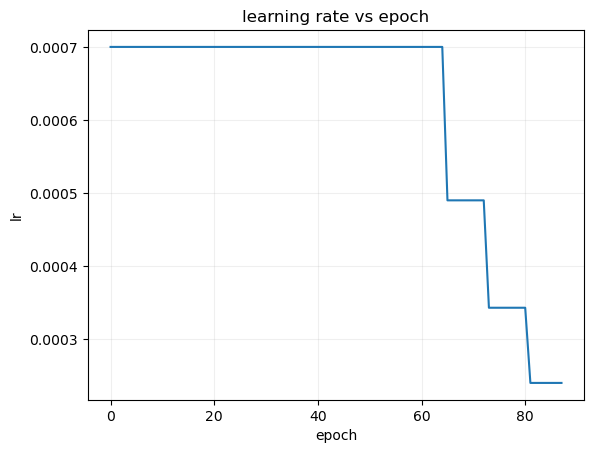

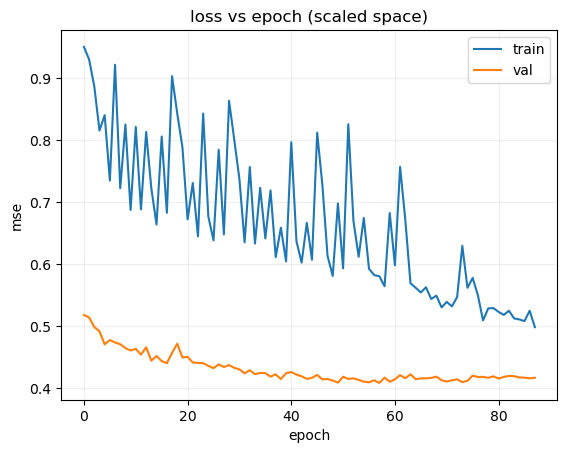

In [46]:
criterion = nn.MSELoss() #loss function
optimizer = torch.optim.Adam(model.parameters(), lr=LR) #optimizer : automatic step for parameters

scheduler = None
if USE_SCHEDULER:
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=SCHED_FACTOR,
        patience=SCHED_PATIENCE,
        threshold=1e-6,
        min_lr=MIN_LR,
        verbose=True
    )

best_val = float("inf")
pat = PATIENCE
best_path = os.path.join(OUT_DIR, "best_model.pt") #path when we save our best model

def run_eval_loss(model, loader):
    model.eval() #switch the model into evaluation mode
    losses = []
    with torch.no_grad(): #stop the gradient calculation
        for xb, yb in loader: #for validation batches
            xb, yb = xb.to(DEVICE), yb.to(DEVICE) #send data to GPU or CPU
            pred = model(xb) #prediction forward pass
            loss = criterion(pred, yb) #MSE calculation
            losses.append(loss.item()) #.item() ==> scalar tensor into float
    return float(np.mean(losses)) if losses else float("inf")

lr_history = []
train_loss_history = []
val_loss_history = []

for epoch in range(1, EPOCHS + 1):
    model.train() #training mode 
    train_losses = [] #batch train losses list

    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)

        optimizer.zero_grad() #put to zero accumulated gradients
        pred = model(xb) #forward pass
        loss = criterion(pred, yb) #calculation MSE
        loss.backward() #back propagation
        optimizer.step() #new weights (from Adam and loss)

        train_losses.append(loss.item()) #stock float of the batch

    train_loss = float(np.mean(train_losses)) #mean loss on all the batches
    val_loss = run_eval_loss(model, val_loader) #mean loss on validation

    if scheduler is not None:
        scheduler.step(val_loss) #scheduler step based on val loss

    current_lr = optimizer.param_groups[0]["lr"]
    lr_history.append(current_lr)
    train_loss_history.append(train_loss)
    val_loss_history.append(val_loss)

    if epoch > 10:
        if val_loss < best_val - 1e-6: #minimal amelioration treshold
            best_val = val_loss
            pat = PATIENCE #patience to maximum
            torch.save(model.state_dict(), best_path) #new best model
        else:
            pat -= 1

        if pat <= 0:
            print("early stopping triggered.")
            break

    if epoch == 1 or epoch % 5 == 0:
        print(f"epoch {epoch:03d} | train {train_loss:.5f} | val {val_loss:.5f} | best {best_val:.5f} | patience {pat} | lr {current_lr:.6g}")

# reload best
model.load_state_dict(torch.load(best_path, map_location=DEVICE))
model.eval()
print("loaded best model from:", best_path)
print("best val loss (scaled space):", best_val)

# save logs
logs_path = os.path.join(OUT_DIR, "train_logs.csv")
pd.DataFrame({
    "epoch": np.arange(1, len(train_loss_history)+1),
    "train_loss": train_loss_history,
    "val_loss": val_loss_history,
    "lr": lr_history,
}).to_csv(logs_path, index=False)
print("saved logs to:", logs_path)

# plot lr
plt.figure()
plt.plot(lr_history)
plt.title("learning rate vs epoch")
plt.xlabel("epoch")
plt.ylabel("lr")
plt.grid(True, alpha=0.2)
plt.show()

# plot losses
plt.figure()
plt.plot(train_loss_history, label="train")
plt.plot(val_loss_history, label="val")
plt.title("loss vs epoch (scaled space)")
plt.xlabel("epoch")
plt.ylabel("mse")
plt.grid(True, alpha=0.2)
plt.legend()
plt.show()

val loss (scaled space): 0.40830668807029724

val metrics (real units):
p  mae : 0.5470730662345886 rmse: 1.1905930041722328 mae/mean[%]: 23.118955181734005


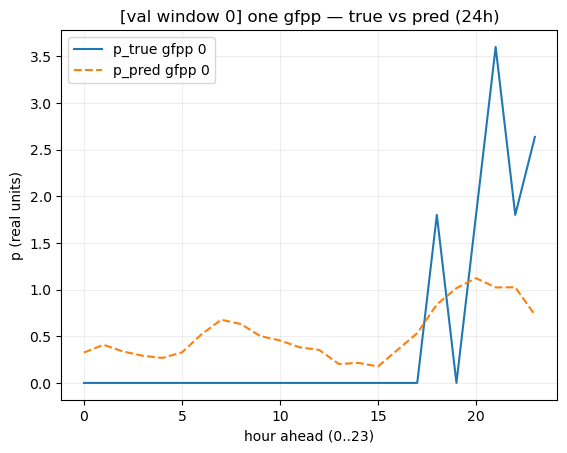

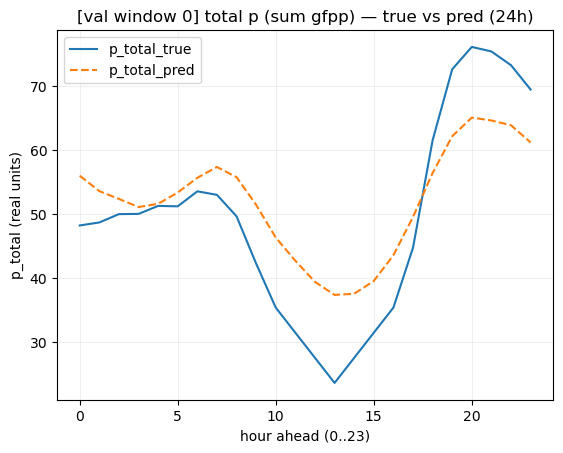

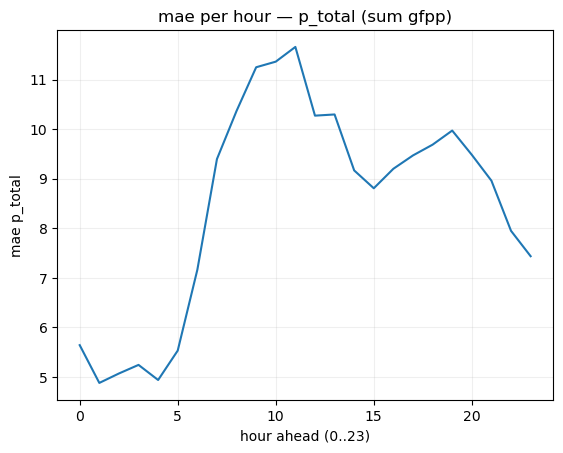

roughness p_total (true mean / pred mean): 4.303084850311279 2.779557943344116


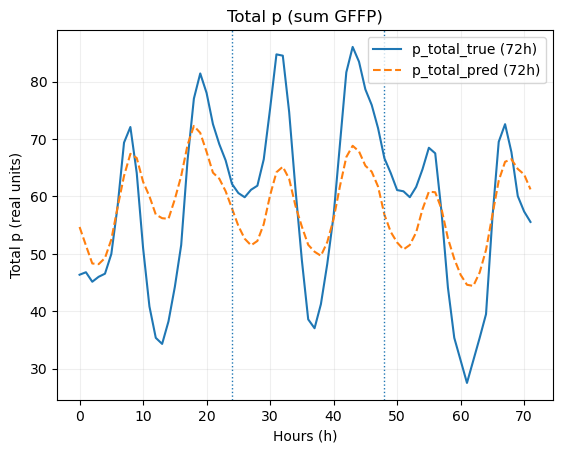

sum p_total over 72h (true / pred): 4237.62353515625 4182.6591796875


In [47]:
# predict val (scaled space)
preds_s = []
with torch.no_grad():
    for xb, _ in val_loader:
        xb = xb.to(DEVICE)
        preds_s.append(model(xb).cpu().numpy())
y_val_pred_s = np.vstack(preds_s)

# inverse scale to real units
y_val_true = scaler_y.inverse_transform(y_val_s)
y_val_pred = scaler_y.inverse_transform(y_val_pred_s)

print("val loss (scaled space):", best_val)

H = HORIZON_HOURS
P = meta["P"]  # number of gfpp

def split_p(y_flat):
    y_p = y_flat.reshape(-1, H, P)  # (N, 24, P)
    return y_p

p_true = split_p(y_val_true)
p_pred = split_p(y_val_pred)

# metrics (global)
p_mae = mean_absolute_error(p_true.reshape(-1), p_pred.reshape(-1))
p_rmse = rmse_flat(p_true.reshape(-1), p_pred.reshape(-1))
p_mae_pct = 100.0 * float(np.mean(np.abs(p_true - p_pred))) / (float(np.mean(np.abs(p_true))) + 1e-9)

print("\nval metrics (real units):")
print("p  mae :", p_mae, "rmse:", p_rmse, "mae/mean[%]:", p_mae_pct)

# totals (sum gfpp) on 24h
p_tot_true = np.sum(p_true, axis=2)  # (N, 24)
p_tot_pred = np.sum(p_pred, axis=2)  # (N, 24)

# plot pred vs true for 1 gfpp (configurable)
GFPP_ID = 0  # change this (0..P-1)
VAL_WIN_IDX = 0  # change this (0..N_val-1)

hours = np.arange(H)

plt.figure()
plt.plot(hours, p_true[VAL_WIN_IDX, :, GFPP_ID], label=f"p_true gfpp {GFPP_ID}")
plt.plot(hours, p_pred[VAL_WIN_IDX, :, GFPP_ID], "--", label=f"p_pred gfpp {GFPP_ID}")
plt.title(f"[val window {VAL_WIN_IDX}] one gfpp — true vs pred (24h)")
plt.xlabel("hour ahead (0..23)")
plt.ylabel("p (real units)")
plt.grid(True, alpha=0.2)
plt.legend()
plt.show()

# plot total p (sum gfpp) 24h
plt.figure()
plt.plot(hours, p_tot_true[VAL_WIN_IDX], label="p_total_true")
plt.plot(hours, p_tot_pred[VAL_WIN_IDX], "--", label="p_total_pred")
plt.title(f"[val window {VAL_WIN_IDX}] total p (sum gfpp) — true vs pred (24h)")
plt.xlabel("hour ahead (0..23)")
plt.ylabel("p_total (real units)")
plt.grid(True, alpha=0.2)
plt.legend()
plt.show()

# mae per hour on total p
mae_p_tot_hour = np.mean(np.abs(p_tot_true - p_tot_pred), axis=0)  # (24,)

plt.figure()
plt.plot(mae_p_tot_hour)
plt.title("mae per hour — p_total (sum gfpp)")
plt.xlabel("hour ahead (0..23)")
plt.ylabel("mae p_total")
plt.grid(True, alpha=0.2)
plt.show()

# roughness on total p
def roughness_1d(x):  # x: (N, H)
    return np.mean(np.abs(x[:, 1:] - x[:, :-1]), axis=1)  # (N,)

r_p_true = roughness_1d(p_tot_true)
r_p_pred = roughness_1d(p_tot_pred)

print("roughness p_total (true mean / pred mean):", float(r_p_true.mean()), float(r_p_pred.mean()))
if r_p_pred.mean() > 1.5 * r_p_true.mean():
    print("[warn] p_total predictions look too oscillatory vs true (roughness too high).")

# =========================
# rolling 72h = 3 x 24h day-ahead on validation timeline (stride=24)
# =========================
Y_p_cols = meta["Y_p_cols"]
X_cols = meta["X_dyn_cols"]

ts_all = df_p_all["ts"].to_numpy()
X_timeline = cons_e_all[X_cols].to_numpy(dtype=np.float32)
Y_timeline = df_p_all[Y_p_cols].to_numpy(dtype=np.float32)

static_vec = static["static_vec"].astype(np.float32)

def build_x_for_t0(t0_idx):
    x_hist = X_timeline[t0_idx - HIST_HOURS:t0_idx, :]  # (72, d)
    x_flat = x_hist.reshape(-1)
    if USE_STATIC and static_vec.size > 0:
        x_flat = np.concatenate([x_flat, static_vec], axis=0)
    return x_flat.astype(np.float32)

def predict_24h_from_x(x_flat):
    x_s = scaler_X.transform(x_flat.reshape(1, -1)).astype(np.float32)
    xb = torch.from_numpy(x_s).float().to(DEVICE)
    with torch.no_grad():
        y_s = model(xb).cpu().numpy()
    y_real = scaler_y.inverse_transform(y_s)[0]  # (24*P,)
    return y_real.astype(np.float32).reshape(H, P)

def true_24h_from_t0(t0_idx):
    return Y_timeline[t0_idx:t0_idx+H, :].astype(np.float32)  # (24,P)

# choose a start time inside validation part
# choose October 1st 2024 00:00 as start time (first 72 hours of October)
t0_ts = np.datetime64("2024-10-03T00:00:00")
t0_idx_candidates = np.where(ts_all == t0_ts)[0]
if len(t0_idx_candidates) == 0:
    # debug help
    raise ValueError(f"cannot find {t0_ts} inside df_p_all ts (min={ts_all.min()}, max={ts_all.max()})")
t0_start = int(t0_idx_candidates[0])

# safety: need enough history and 72h future
if t0_start - HIST_HOURS < 0 or t0_start + 72 > len(ts_all):
    raise ValueError("not enough history/future for rolling 72h at chosen t0_start")

p_true_72 = []
p_pred_72 = []
for k in range(3):
    t0 = t0_start + k * 24
    x_flat = build_x_for_t0(t0)
    p_pred_24 = predict_24h_from_x(x_flat)
    p_true_24 = true_24h_from_t0(t0)
    p_true_72.append(p_true_24)
    p_pred_72.append(p_pred_24)

p_true_72 = np.concatenate(p_true_72, axis=0)  # (72,P)
p_pred_72 = np.concatenate(p_pred_72, axis=0)  # (72,P)

p_tot_true_72 = np.sum(p_true_72, axis=1)  # (72,)
p_tot_pred_72 = np.sum(p_pred_72, axis=1)  # (72,)

hours_72 = np.arange(72)

plt.figure()
plt.plot(hours_72, p_tot_true_72, label="p_total_true (72h)")
plt.plot(hours_72, p_tot_pred_72, "--", label="p_total_pred (72h)")
plt.axvline(24, linestyle=":", linewidth=1)
plt.axvline(48, linestyle=":", linewidth=1)
plt.title("Total p (sum GFFP)")
plt.xlabel("Hours (h)")
plt.ylabel("Total p (real units)")
plt.grid(True, alpha=0.2)
plt.legend()
plt.show()

print("sum p_total over 72h (true / pred):", float(p_tot_true_72.sum()), float(p_tot_pred_72.sum()))

t0_start = 7320 | ts = 2024-11-01 00:00:00


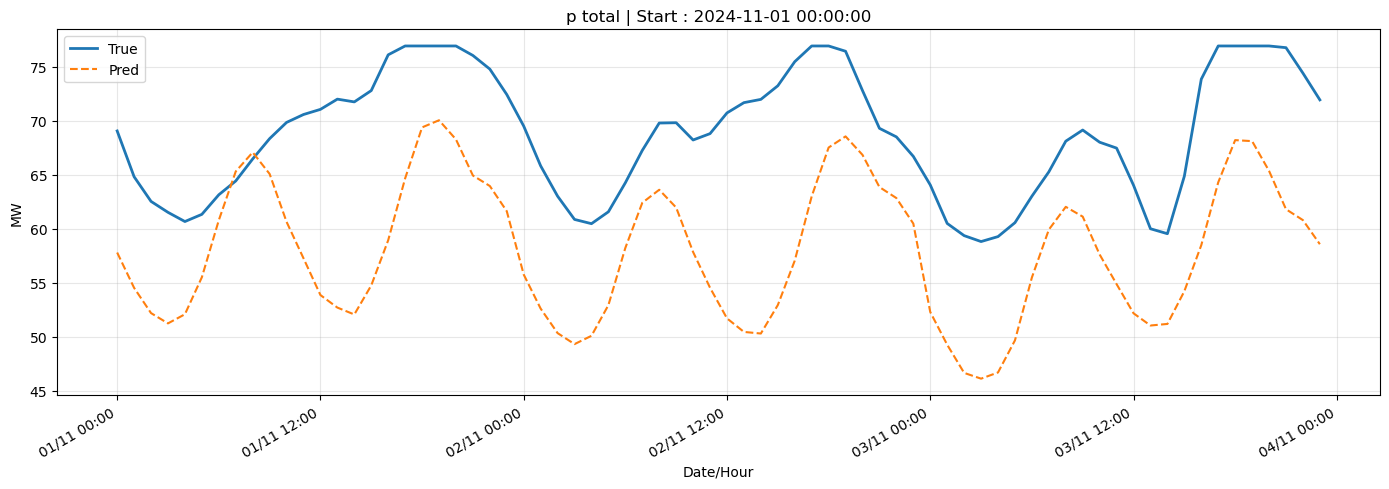

Figure sauvegardée dans : ./runs_mlp_elec_only\rolling_72h_p_total_elec_only.png
p_true_72 shape : (72, 24)
p_pred_72 shape : (72, 24)


In [48]:
# ============================================================
# CELL — Plot rolling 72h (3 jours) compatible ELEC ONLY
# ============================================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import torch

ALIGN_TS = "2024-11-01 00:00:00"   # date de départ
N_DAYS   = 3                       # nombre de jours affichés

H    = HORIZON_HOURS   # 24
HIST = HIST_HOURS      # 72
P    = meta["P"]

use_static = False

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def build_X_for_t0_elec(t0_idx, cons_e_all, static_vec, HIST=72, use_static=False):
    x_hist = (
        cons_e_all.iloc[t0_idx - HIST:t0_idx]
        .drop(columns=["ts"], errors="ignore")
        .to_numpy(dtype=np.float32)
    )
    assert x_hist.shape[0] == HIST, f"Historique invalide: {x_hist.shape}"
    
    x_flat = x_hist.reshape(-1)
    
    if use_static:
        x_flat = np.concatenate([x_flat, static_vec.astype(np.float32)], axis=0)
    
    return x_flat.astype(np.float32)

def get_true_p_for_horizon(t0_idx, df_p_all, H=24):
    Y_p_cols = [c for c in df_p_all.columns if str(c).startswith("p_")]
    return df_p_all.iloc[t0_idx:t0_idx+H][Y_p_cols].to_numpy(dtype=np.float32)

def model_predict_24h_elec(x_flat, model, scaler_X, scaler_y, device):
    x_s = scaler_X.transform(x_flat.reshape(1, -1)).astype(np.float32)
    xb  = torch.from_numpy(x_s).to(device)
    
    model.eval()
    with torch.no_grad():
        y_s = model(xb).cpu().numpy()
    
    return scaler_y.inverse_transform(y_s)[0].astype(np.float32)

# ------------------------------------------------------------
# Recherche du timestamp de départ
# ------------------------------------------------------------
target = pd.Timestamp(ALIGN_TS)
ts_arr = pd.to_datetime(df_p_all["ts"]).to_numpy()

matches = np.where(ts_arr == np.datetime64(target))[0]
if len(matches) == 0:
    raise ValueError(f"{ALIGN_TS} introuvable dans df_p_all['ts'].")

t0_start = int(matches[0])

N_total = len(df_p_all)
assert t0_start - HIST >= 0, "Pas assez d'historique avant ALIGN_TS."
assert t0_start + N_DAYS * H <= N_total, "Pas assez de points après ALIGN_TS."

print(f"t0_start = {t0_start} | ts = {df_p_all.iloc[t0_start]['ts']}")

# ------------------------------------------------------------
# Rolling prediction sur 3 jours
# ------------------------------------------------------------
static_vec = np.zeros(0, dtype=np.float32)

p_true_72 = []
p_pred_72 = []
ts_72     = []

for day in range(N_DAYS):
    t0 = t0_start + day * H

    x_flat = build_X_for_t0_elec(
        t0_idx=t0,
        cons_e_all=cons_e_all,
        static_vec=static_vec,
        HIST=HIST,
        use_static=use_static
    )

    y_pred_flat = model_predict_24h_elec(x_flat, model, scaler_X, scaler_y, DEVICE)

    p_pred_24 = y_pred_flat.reshape(H, P)
    p_true_24 = get_true_p_for_horizon(t0, df_p_all, H=H)

    p_true_72.append(p_true_24)
    p_pred_72.append(p_pred_24)
    ts_72.append(pd.to_datetime(df_p_all.iloc[t0:t0+H]["ts"]).to_numpy())

p_true_72 = np.concatenate(p_true_72, axis=0)   # shape: (72, P)
p_pred_72 = np.concatenate(p_pred_72, axis=0)   # shape: (72, P)
ts_72     = np.concatenate(ts_72, axis=0)       # shape: (72,)

# Somme totale sur toutes les GFPP
p_tot_true_72 = np.sum(p_true_72, axis=1)
p_tot_pred_72 = np.sum(p_pred_72, axis=1)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(ts_72, p_tot_true_72, label="True",   lw=2,   color="#1f77b4")
ax.plot(ts_72, p_tot_pred_72, label="Pred", lw=1.5, color="#ff7f0e", ls="--")

# Lignes verticales jour +1 et jour +2

ax.set_ylabel("MW")
ax.set_xlabel("Date/Hour")
ax.set_title(f"p total | Start : {ALIGN_TS}")
ax.legend()
ax.grid(True, alpha=0.3)

ax.xaxis.set_major_formatter(mdates.DateFormatter("%d/%m %H:00"))
fig.autofmt_xdate(rotation=30)
fig.tight_layout()

save_path = os.path.join(OUT_DIR, "rolling_72h_p_total_elec_only.png")
fig.savefig(save_path, dpi=130, bbox_inches="tight")
plt.show()

print("Figure sauvegardée dans :", save_path)
print("p_true_72 shape :", p_true_72.shape)
print("p_pred_72 shape :", p_pred_72.shape)

=== ELEC ONLY | Global metrics on validation ===
MAE            : 8.466412
RMSE           : 10.690953
MAE/mean       : 0.149077
Roughness err  : 1.383546
Roughness true : 4.268160
Roughness pred : 2.884614


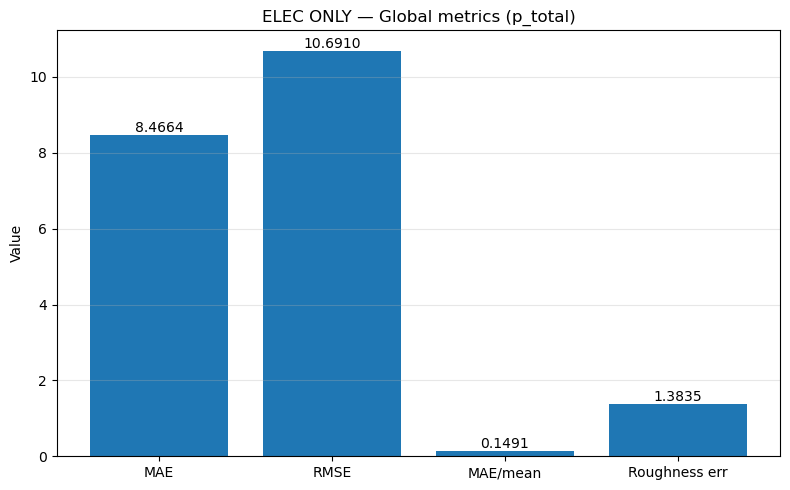

Figure saved to: ./runs_mlp_elec_only\global_metrics_elec_only.png


In [49]:
# ============================================================
# CELL — Global metrics plot | ELEC ONLY
# ============================================================
import os
import numpy as np
import matplotlib.pyplot as plt
import torch

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def rmse(y_true, y_pred):
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

def mae(y_true, y_pred):
    return float(np.mean(np.abs(y_true - y_pred)))

def roughness(x):
    x = np.asarray(x).reshape(-1)
    if len(x) < 2:
        return 0.0
    return float(np.mean(np.abs(np.diff(x))))

# ------------------------------------------------------------
# Prédictions globales sur le set de validation
# ------------------------------------------------------------
model.eval()
with torch.no_grad():
    pred_s = model(torch.from_numpy(X_val_s).to(DEVICE)).cpu().numpy()

# retour échelle réelle
pred_real = scaler_y.inverse_transform(pred_s)     # shape: (N, 24*P)
true_real = y_val.copy() if 'y_val' in globals() else scaler_y.inverse_transform(y_val_s)

# reshape en (N, H, P)
P = meta["P"]
H = HORIZON_HOURS

pred_real_3d = pred_real.reshape(-1, H, P)
true_real_3d = true_real.reshape(-1, H, P)

# total élec
p_pred_total = pred_real_3d.sum(axis=2).reshape(-1)
p_true_total = true_real_3d.sum(axis=2).reshape(-1)

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------
metric_mae       = mae(p_true_total, p_pred_total)
metric_rmse      = rmse(p_true_total, p_pred_total)
metric_mae_mean  = metric_mae / (np.mean(np.abs(p_true_total)) + 1e-12)
rough_true       = roughness(p_true_total)
rough_pred       = roughness(p_pred_total)
metric_roughness = abs(rough_pred - rough_true)

metrics = {
    "MAE": metric_mae,
    "RMSE": metric_rmse,
    "MAE/mean": metric_mae_mean,
    "Roughness err": metric_roughness
}

print("=== ELEC ONLY | Global metrics on validation ===")
for k, v in metrics.items():
    print(f"{k:<15}: {v:.6f}")
print(f"{'Roughness true':<15}: {rough_true:.6f}")
print(f"{'Roughness pred':<15}: {rough_pred:.6f}")

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
names  = list(metrics.keys())
values = list(metrics.values())

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(names, values)

ax.set_title("ELEC ONLY — Global metrics (p_total)")
ax.set_ylabel("Value")
ax.grid(True, axis="y", alpha=0.3)

for b, v in zip(bars, values):
    ax.text(b.get_x() + b.get_width()/2, b.get_height(), f"{v:.4f}",
            ha="center", va="bottom", fontsize=10)

fig.tight_layout()

save_path = os.path.join(OUT_DIR, "global_metrics_elec_only.png")
fig.savefig(save_path, dpi=140, bbox_inches="tight")
plt.show()

print("Figure saved to:", save_path)

In [50]:
print(p_true.shape)
print(np.mean(p_true))
print(np.min(p_true), np.max(p_true))

(30, 24, 24)
2.36634
-4.175612e-07 20.0
